In [1]:
# rm(list=ls())
library(limma)
library(parallel)
library(jsonlite)
library(UpSetR)
library(ggplot2)
library(ape)
library(data.table)
library(reshape2)
library(dplyr)
library(tidyr)



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths




In [156]:
source(file.path(PHYLOGWAS_ROOT, "src/S00_basicFunction.R"))

# data loading & processing

In [3]:
mappingFile = read.table(file.path(PHYLOGWAS_ROOT, "data/DEG_mappingFiles/OG_mapping_Oryza_sativa.IRGSP-1.0.cds.all.txt"))
mappingFile2 = read.table(file.path(PHYLOGWAS_ROOT, "data/OGToZm_mapping_v2.txt"))

colnames(mappingFile) = c("OsID","OG")
colnames(mappingFile2) = c("ZmID","OG")

mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)


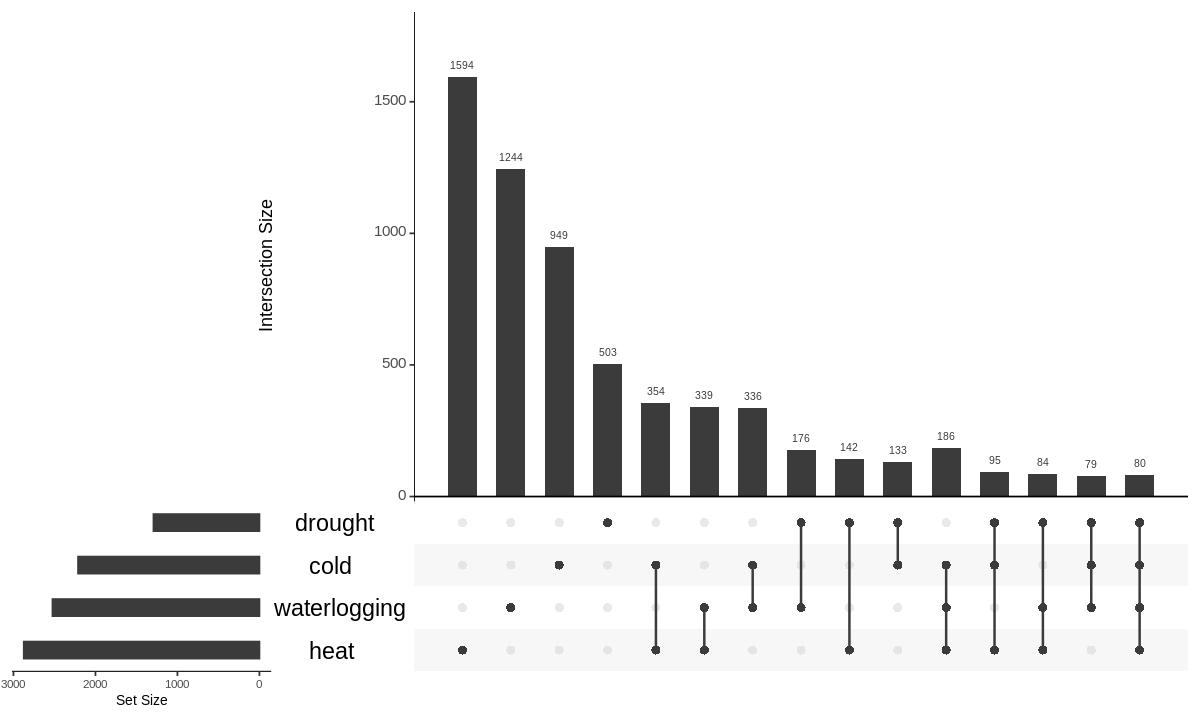

In [4]:
envResponsiveGenes = read_json(file.path(PHYLOGWAS_ROOT, "output/candidateGenes/consistentEnvResponsiveGenes.json"))

options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(envResponsiveGenes),text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [5]:
envResponsiveGenes = lapply(envResponsiveGenes,unlist)

In [6]:
envResponsiveGenesMerged = lapply(envResponsiveGenes,function(x) subset(mappingFileMerged,OG%in%x))

In [7]:
names(envResponsiveGenesMerged)

[1] "cold"         "heat"         "drought"      "waterlogging"

In [33]:
for (i in 1:4){
    write.table(envResponsiveGenesMerged[[i]],
                paste0(file.path(PHYLOGWAS_ROOT, "output/candidateGenes/consistentEnvResponsiveGenes."),
                       names(envResponsiveGenesMerged)[i],".txt"),quote = F, sep = "\t",row.names = F)
}

In [8]:
testResList = mclapply(list.files(file.path(PHYLOGWAS_ROOT, "output/finalModels_20251002/"),
                                  pattern = "ASREML_res_empPadded.txt",full.names = T,recursive = T),
                       read.table,header = T,mc.cores = 5)

# Fig 5a

In [84]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig5a1_v2.png"),width = 17.4,height = 8.7*2/3,units = "cm",res = 600,pointsize = 8)
layout(matrix(1:3,nrow = 1),widths = c(1.3,1,1))
for(i in 1:3){
    if (i ==1) par(mar= c(5,5,5,1))
    else par(mar= c(5,1,5,1))
    hist(as.numeric(testResList[[i]]$p),
         pch = 19,axes = T,col = "grey",border = "grey",breaks = seq(0,1,0.001),
         xlab = "",ylab = "",yaxt = ifelse(i ==1, 's','n'),
         main = paste0("envPC",i,"\n",c("Temperature","Evapotranspiration","Soil Permeability")[i]),cex.main = 1.75)
    hist(as.numeric(testResList[[i]]$p)[as.numeric(testResList[[i]]$p) <= 0.001],
         pch = 19,axes = T,col = "red",border = "red",breaks = seq(0,0.001,0.001),
         xlab = "",ylab = "",yaxt = ifelse(i ==1, 's','n'),add = T)

    if(i == 1) mtext("Frequency",2,line = 3)
    if(i == 2) mtext("P-value",1,line = 3)
}
dev.off()

pdf 
  2

In [83]:
sapply(testResList,function(x) sum(x$p<=1e-3))
sapply(testResList,function(x) sum(x$emp_p<=1e-3,na.rm = T))

[1] 275 204 211 162 180

[1] 160 109  68  36  30

In [22]:
candidateOGList = lapply(testResList, function(x) na.omit(x$OG[x$emp_p<=1e-3]))

In [25]:
names(candidateOGList) = paste("envPC",1:5)

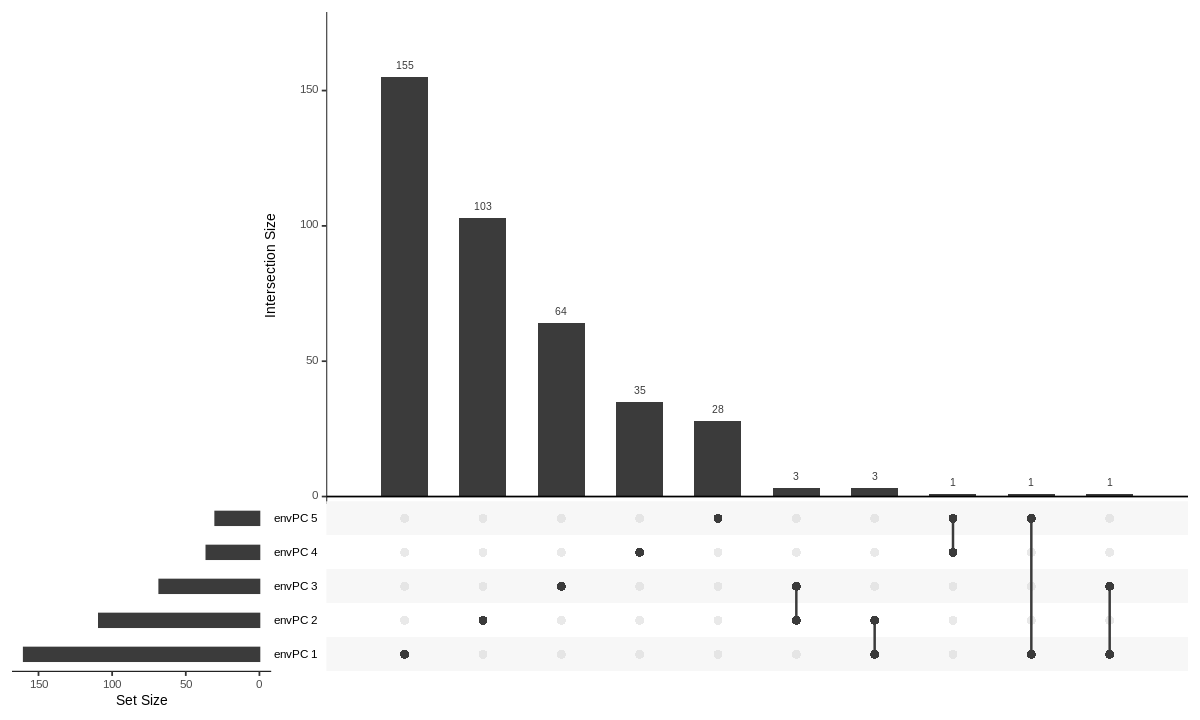

In [17]:
upset(fromList(candidateOGList))

In [18]:
mat = sapply(testResList[1:3],function(x) table(cut(na.omit(x$emp_p),c(0,.001,0.01,.05,1),include.lowest = T)))

## piechart

In [20]:
colnames(mat) = paste0(sapply(testResList[1:3],function(x) sum(x$p<=1e-3)))

# Melt to long format
df <- as.data.frame(mat) %>%
  mutate(Bin = rownames(.)) %>%
  melt(id.vars = "Bin", variable.name = "Column", value.name = "Count")

df$Bin = factor(df$Bin,levels = c("[0,0.001]","(0.001,0.01]","(0.01,0.05]","(0.05,1]"))
# Compute per-column totals and percentages
df <- df %>%
  group_by(Column) %>%
  mutate(Total = sum(Count),
         Prop = Count / Total) %>%
  ungroup()

# Now we assign a “width” aesthetic to make pies bigger for larger totals
# We pick a scaling: e.g. width = sqrt(Total) (so area ~ Total)
# (You can pick any transform you like)
df <- df %>%
  mutate(pie_width = Total)

# Plot
p1 = ggplot(df, aes(x = 1+(pie_width/2), y = Prop, fill = Bin, width = pie_width)) +
  geom_col(color = "grey",linewidth = .25) +
  coord_polar(theta = "y",start = 3.14/2) +
  scale_fill_manual(values = c("firebrick","darkorange","gold","grey"))+
  facet_wrap(~ Column,nrow = 1,scale = "fixed") +
  # add labels in slices
  geom_text(aes(label = Count),
            position = position_stack(vjust = c(0.75,.5,.5,.5)), size = 3,col = "white") +
  theme_void() +
  theme(legend.position = "bottom",strip.text.x.top = element_text(size = 12),
        legend.text = element_text(size = 6),legend.title = element_text(size = 8),
        legend.key.size = unit(.1,units = "inch"))+
  labs(fill = "Empirical\np-value")


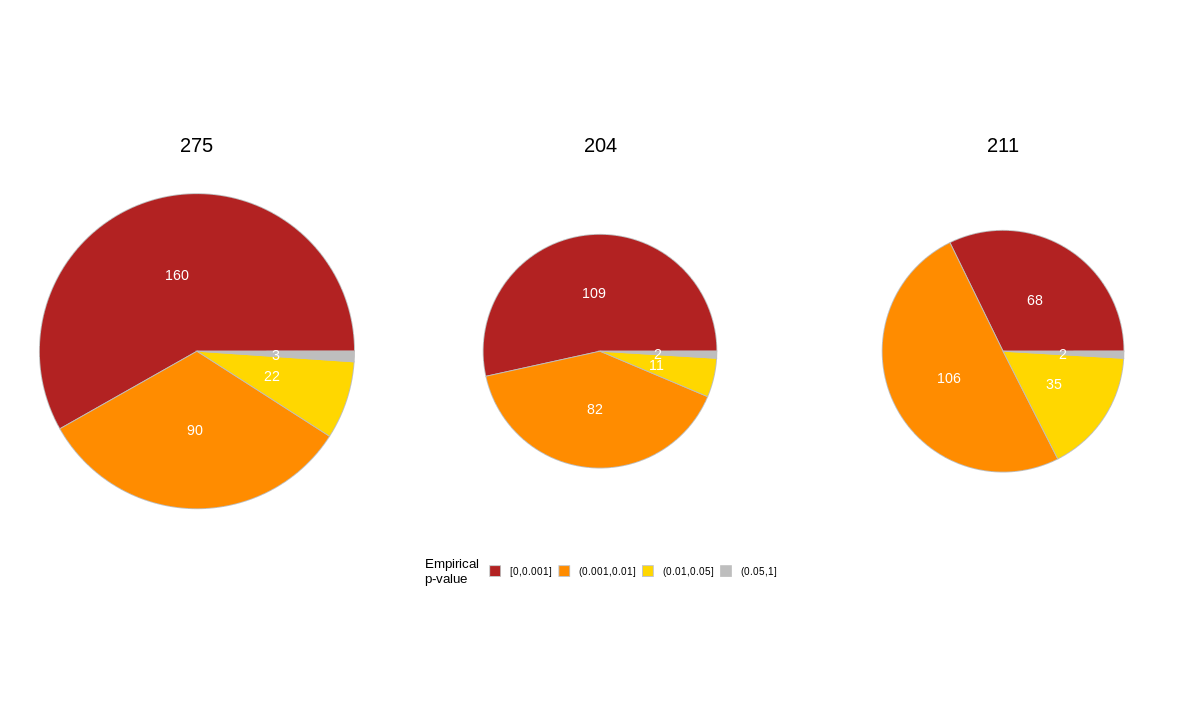

In [37]:
p1

In [1682]:
ggsave(file.path(PHYLOGWAS_ROOT, "output/figure/Fig5b.png"),p1,device = "png",
       width = 16.4,height = 8.7/2,units = "cm",dpi = 600)

# enrichment analysis

In [22]:
oddsRatio = c()
pVal = c()
for(i in 1:5){
    tmpTest = lapply(envResponsiveGenes,function(x) {
        fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,x),alternative = "greater")
        })
    oddsRatio = rbind(oddsRatio,sapply(tmpTest,function(x) x$estimate))
    pVal = rbind(pVal,sapply(tmpTest,function(x) x$p.value))
}


In [23]:
oddsRatio
pVal

cold.odds ratio,heat.odds ratio,drought.odds ratio,waterlogging.odds ratio
1.2459182,0.9731892,1.790271,1.1512038
1.1205478,1.4500154,1.330375,1.4056970
2.3445826,1.0447860,1.427152,1.0825121
0.4849017,0.3577187,0.422890,0.4194476
0.9181080,0.9363522,1.053217,1.4252763


cold,heat,drought,waterlogging
0.20602725,0.58168006,0.0229551,0.3042498
0.39464397,0.08527999,0.2552218,0.1218833
0.00531536,0.50181193,0.2632937,0.4669063
0.91291402,0.97111286,0.9049475,0.9462554
0.64280328,0.62817977,0.5764456,0.3071740


In [24]:
colnames(oddsRatio) = colnames(pVal)
rownames(oddsRatio) = paste0("envPC",1:5)
rownames(pVal) = rownames(oddsRatio)

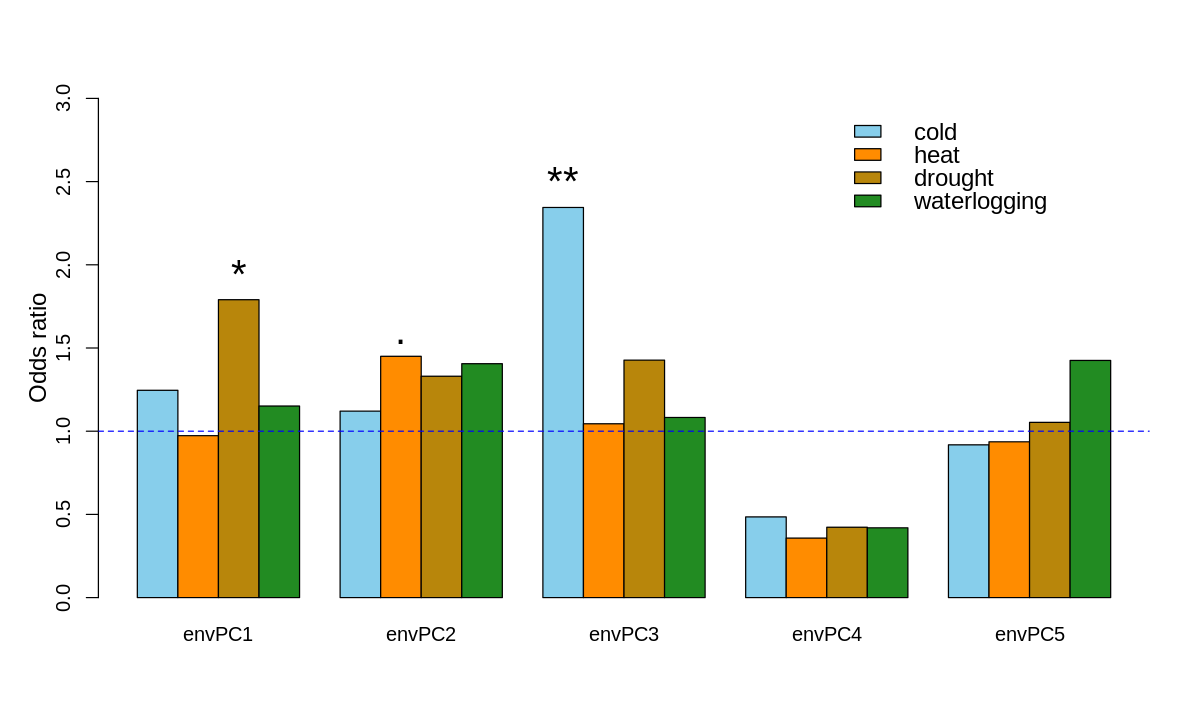

In [25]:
# Figure 5B
bp = barplot(t(oddsRatio),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio),ylab = "",args.legend = list(bty = 'n',cex = 1.2),cex.axis = 1)
mtext("Odds ratio",2,line = 2,cex = 1.2)
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio),labels = ifelse(t(pVal)<.01,"**",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.01&t(pVal)<.05,"*",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.05&t(pVal)<.1,".",""),pos = 3,cex = 2)


In [1666]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig5c.png"),width = 17.4,height = 8.7*2/3,units = "cm",pointsize = 8,res = 600)
par(mar = c(1,3,1,1))
bp = barplot(t(oddsRatio[1:3,]),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio[1:3,]),ylab = "",args.legend = list(bty = 'n',cex = 1.2),cex.axis = 1)
mtext("Odds ratio",2,line = 2,cex = 1.2)
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])<.01,"**",""),pos = 3,cex = 2)
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])>.01&t(pVal[1:3,])<.05,"*",""),pos = 3,cex = 2)
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])>.05&t(pVal[1:3,])<.1,".",""),pos = 3,cex = 2)

dev.off()

pdf 
  2

In [1663]:
head(oddsRatio)

,cold,heat,drought,waterlogging
envPC1,1.2459182,0.9731892,1.790271,1.1512038
envPC2,1.1205478,1.4500154,1.330375,1.4056970
envPC3,2.3445826,1.0447860,1.427152,1.0825121
envPC4,0.4849017,0.3577187,0.422890,0.4194476
envPC5,0.9181080,0.9363522,1.053217,1.4252763


In [19]:
for(i in 1:5){
    print(fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,
                                 Reduce("intersect",envResponsiveGenes[c(2,4)])),alternative = "greater"))
}


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.7733
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.2542356       Inf
sample estimates:
odds ratio 
 0.7553084 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.1643
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.7096737       Inf
sample estimates:
odds ratio 
  1.669776 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 1
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
   0 Inf
sample estimates:
odds ratio 
         0 


	Fisher's Exact Test for Count D

In [299]:
for (i in 1:3){
    testResList[[i]] = merge(testResList[[i]],mappingFileMerged,by ="OG")
}

In [309]:
for (i in 1:3){
    write.table(testResList[[i]],
                paste0(file.path(PHYLOGWAS_ROOT, "output/finalModels_20251002/envPC_"),i,"/ASREML_res_empPadded_homologAdded.txt"),quote = F,sep = "\t",row.names = F)
}

## GO enrichment

In [41]:
library(topGO)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: graph


Attaching package: ‘graph’


The following objects are masked from ‘package:ape’:

    complement, degree, edges


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, se

In [42]:
GODB <- readMappings(file.path(PHYLOGWAS_ROOT, "data/Zm00001eb.1.fulldata_goList.txt"),IDsep = ",")
background = intersect(names(GODB),substr(mappingFileMerged$ZmID,1,15))
# background = names(GODB)

In [43]:
tgd1 = list()
GO_res_table = list()
for (i in 1:5){
    tmp=factor(as.integer(background%in%substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[i]],3],1,15)))
    names(tmp)=background
    tgd1[[i]]=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
    resTopGO.classic=runTest(tgd1[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd1[[i]], algorithm = "elim", statistic = "Fisher")
    GO_res_table[[i]]=GenTable(tgd1[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}



Building most specific GOs .....

	( 3729 GO terms found. )


Build GO DAG topology ..........

	( 5296 GO terms and 11198 relations. )


Annotating nodes ...............

	( 12805 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 15:	2 nodes to be scored	(0 eliminated genes)


	 Level 14:	5 nodes to be scored	(0 eliminated genes)


	 Level 13:	9 nodes to be scored	(0 eliminated genes)


	 Level 12:	17 nodes to be scored	(0 eliminated genes)


	 Level 11:	27 nodes to be scored	(0 eliminated genes)


	 Level 10:	53 nodes to be scored	(0 eliminated genes)


	 Level 9:	96 nodes to be scored	(36 eliminated genes)


	 Level 8:	103 nodes to be scored	(133 eliminated genes)


	 Level 7:	136 nodes to be scored	(133 eliminated genes)


	 Lev

In [44]:
tgd2 = list()
GO_res_table_CC = list()
for (i in 1:5){
    tmp=factor(as.integer(background%in%substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[i]],3],1,15)))
    names(tmp)=background
    tgd2[[i]]=new( "topGOdata", ontology="CC", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
    resTopGO.classic=runTest(tgd2[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd2[[i]], algorithm = "elim", statistic = "Fisher")
    GO_res_table_CC[[i]]=GenTable(tgd2[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}



Building most specific GOs .....

	( 827 GO terms found. )


Build GO DAG topology ..........

	( 955 GO terms and 1651 relations. )


Annotating nodes ...............

	( 14001 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 174 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 174 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 10:	7 nodes to be scored	(0 eliminated genes)


	 Level 9:	16 nodes to be scored	(0 eliminated genes)


	 Level 8:	33 nodes to be scored	(0 eliminated genes)


	 Level 7:	30 nodes to be scored	(0 eliminated genes)


	 Level 6:	26 nodes to be scored	(0 eliminated genes)


	 Level 5:	22 nodes to be scored	(131 eliminated genes)


	 Level 4:	18 nodes to be scored	(131 eliminated genes)


	 Level 3:	19 nodes to be scored	(131 eliminated genes)


	 Level 2:	2 nodes to be scored	(131 eliminated genes)


	 Level 1:	

In [64]:
topGOTab = list()
for (i in 1:5){
    GO_res_table[[i]]$foldER = GO_res_table[[i]]$Significant/GO_res_table[[i]]$Expected
    GO_res_table[[i]]$sig.OG = sapply(genesInTerm(tgd1[[i]],GO_res_table[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,substr(ZmID,1,15)%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })

    topGOTab[[i]] = subset(GO_res_table[[i]],Fisher.weight01<0.05 & Significant >1&foldER>3)
    topGOTab[[i]] = head(topGOTab[[i]][order(topGOTab[[i]]$Fisher.weight01),],10)
}
topGOTab

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0090376,seed trichome differentiation,25,3,0.23,2,0.0016,0.0016,13.043478,"OG0012377,OG0015449,OG0023821"
2,GO:0051301,cell division,307,9,2.85,4,0.0022,0.0022,3.157895,"OG0002585,OG0005670,OG0011145,OG0016821,OG0017837,OG0018950,OG0020521,OG0023821,OG0027084"
3,GO:0006890,"retrograde vesicle-mediated transport, Golgi to endoplasmic reticulum",30,3,0.28,5,0.0026,0.0026,10.714286,"OG0003084,OG0013785,OG0017435"
4,GO:0009862,"systemic acquired resistance, salicylic acid mediated signaling pathway",9,2,0.08,6,0.0030,0.0030,25.000000,"OG0002326,OG0011353"
5,GO:0035246,peptidyl-arginine N-methylation,11,2,0.10,9,0.0045,0.0045,20.000000,"OG0013325,OG0015403"
6,GO:0000725,recombinational repair,74,4,0.69,10,0.0049,0.0049,5.797101,"OG0010826,OG0015268,OG0016595,OG0019946"
9,GO:0010337,regulation of salicylic acid metabolic process,15,2,0.14,18,0.0083,0.0083,14.285714,"OG0006053,OG0011444"
10,GO:0010167,response to nitrate,16,2,0.15,20,0.0094,0.0094,13.333333,"OG0011444,OG0014903"
12,GO:0098656,anion transmembrane transport,104,4,0.97,22,0.0160,0.0160,4.123711,"OG0003913,OG0012523,OG0014903,OG0015981"


In [67]:
topGOTab_CC = list()
for (i in 1:3){
    GO_res_table_CC[[i]]$foldER = GO_res_table_CC[[i]]$Significant/GO_res_table_CC[[i]]$Expected
    GO_res_table_CC[[i]]$sig.OG = sapply(genesInTerm(tgd2[[i]],GO_res_table_CC[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,substr(ZmID,1,15)%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })


    topGOTab_CC[[i]] = subset(GO_res_table_CC[[i]],Fisher.weight01<0.05 & Significant >1&foldER>2)
    topGOTab_CC[[i]] = head(topGOTab_CC[[i]][order(topGOTab_CC[[i]]$Fisher.weight01),],10)
}
topGOTab_CC

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0009505,plant-type cell wall,131,6,1.09,1,0.0008,0.0008,5.504587,"OG0002326,OG0006169,OG0014032,OG0014896,OG0017878,OG0030526"
2,GO:0005576,extracellular region,683,12,5.71,4,0.0117,0.0117,2.101576,"OG0001269,OG0002267,OG0002631,OG0004860,OG0011444,OG0014896,OG0015016,OG0015402,OG0016796,OG0017878,OG0023821,OG0030526"
3,GO:0048046,apoplast,166,5,1.39,5,0.0128,0.0128,3.597122,"OG0002267,OG0011444,OG0015402,OG0016796,OG0017878"
8,GO:0005741,mitochondrial outer membrane,42,2,0.35,11,0.0480,0.0480,5.714286,"OG0009580,OG0021070"
,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0009504,cell plate,18,2,0.11,1,0.0050,0.0050,18.181818,"OG0007390,OG0020494"
3,GO:0000178,exosome (RNase complex),24,2,0.14,3,0.0088,0.0088,14.285714,"OG0008919,OG0015467"
8,GO:0005802,trans-Golgi network,214,4,1.27,9,0.0383,0.0383,3.149606,"OG0004900,OG0016407,OG0025267,OG0026002"


In [68]:
for (i in 1:3){
    write.table(GO_res_table[[i]],paste0(file.path(PHYLOGWAS_ROOT, "output/GOenrichment_envPC"),i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


In [69]:
for (i in 1:3){
    write.table(GO_res_table_CC[[i]],paste0(file.path(PHYLOGWAS_ROOT, "output/GOenrichment_CC_envPC"),i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


In [190]:
length(unlist(genesInTerm(tgd2[[1]],whichGO = "GO:0110165")))
length(background)

[1] 13944

[1] 15905

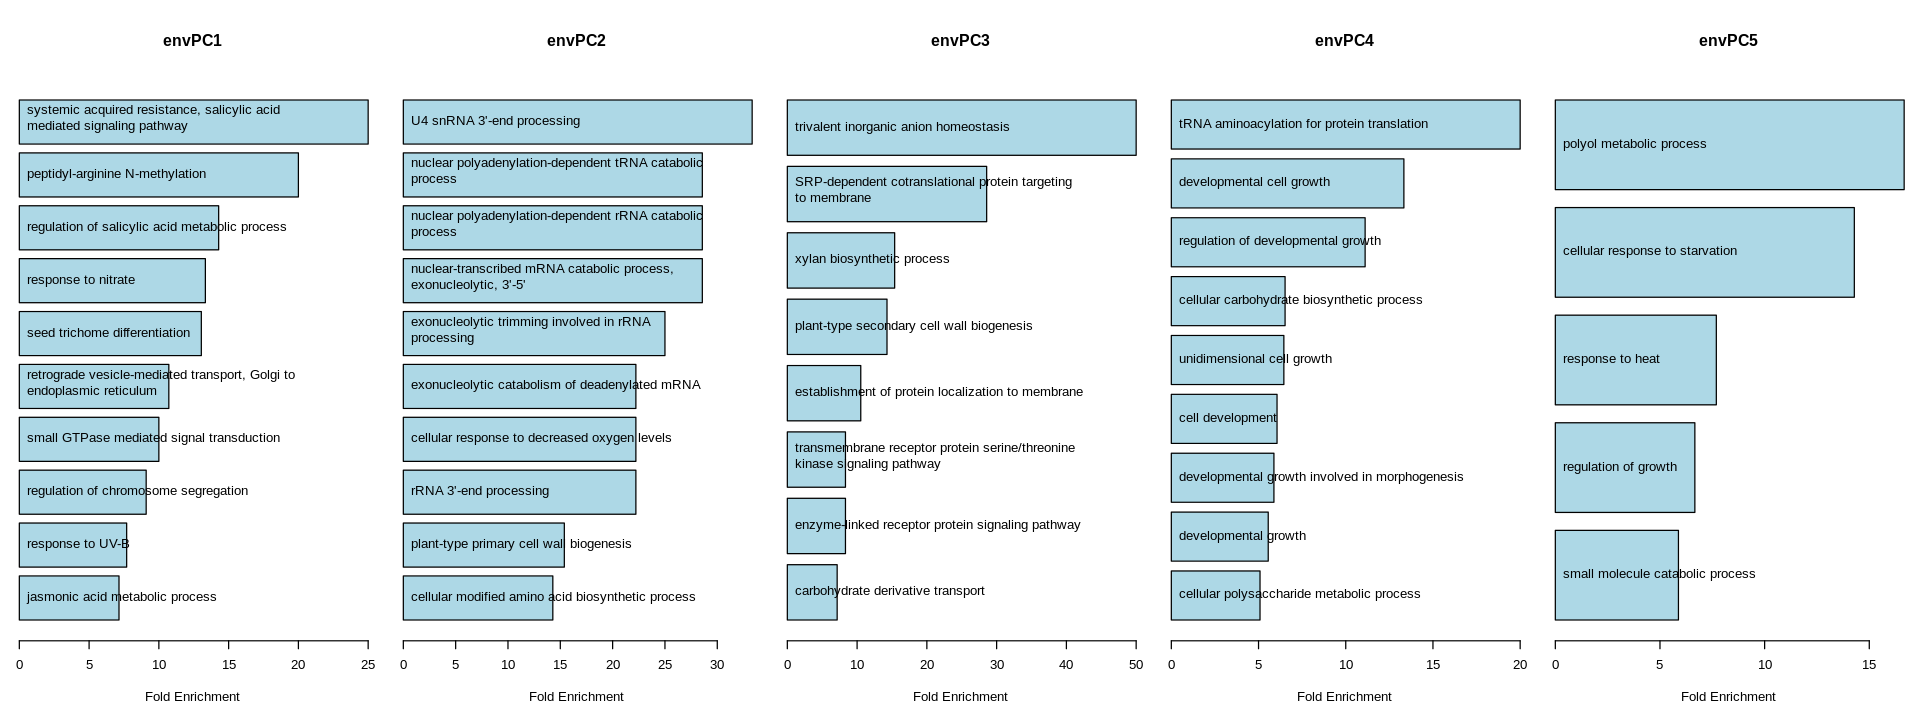

In [1649]:
options(repr.plot.width=16, repr.plot.height=6)
par(mar= c(5,1,5,1),mfrow = c(1,5))
for(i in 1:5){
    bp = barplot(topGOTab[[i]]$foldER,horiz = T,names.arg = NULL,las = 1,xlab = "Fold Enrichment",col = "lightblue",
                 main = paste0("envPC",i))
#     abline(v = 1, col = "red",lty = 2,lwd = 3)
    tmpLab = sapply(topGOTab[[i]]$Term,function(x) paste(strwrap(x,width = 50),collapse = "\n"))
    text(0,bp,tmpLab,col ="black",pos = 4)
}


In [250]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig5d_v2.png"),width = 15.6,height = 8.7,units = "cm",pointsize = 8,res = 600)
par(mar= c(5,1,1,1),mfrow = c(1,3))
for(i in 1:3){
    bp = barplot(rev(-log10(as.numeric(topGOTab[[i]]$Fisher.weight01))),horiz = T,names.arg = NULL,las = 1,border = NA,
                 xlab = expression(-log[10](P)),col = "lightblue")
#     abline(v = 1, col = "red",lty = 2,lwd = 3)
    tmpLab = sapply(topGOTab[[i]]$Term,function(x) paste(strwrap(x,width = 45),collapse = "\n"))
    text(0,bp,rev(tmpLab),col ="black",pos = 4,cex = 1.2)
}
dev.off()

pdf 
  2

In [95]:
for(i in 1:3){
    write.table(candidateOGList[[i]],paste0(file.path(PHYLOGWAS_ROOT, "output/candidateOG_envPC"),i,".txt"),
                quote = F,col.names = F,row.names = F)
}


## cellular localization by deepGO

In [70]:
GO_CC = fread(file.path(PHYLOGWAS_ROOT, "data/poaceaeHelixerOG_ancSeq_gapRemoved_v2_uppercase_output_CC_f.gmt"),data.table = F,fill = T,header = F)

In [71]:
GO_CC <- GO_CC %>%
  unite("OGs", V3:ncol(GO_CC), sep = ",", na.rm = TRUE)
GOCCGene = lapply(GO_CC[,3],function(x) unique(as.vector(limma::strsplit2(x,","))))
GOCCGene_term = GOCCGene
names(GOCCGene) = GO_CC[,2]
names(GOCCGene_term) = GO_CC[,1]                  
filterIdx = sapply(GOCCGene,function(x) sum(x%in%testResList[[1]]$OG))>50&sapply(GOCCGene,function(x) sum(x%in%testResList[[1]]$OG))<10000
GOCCGene = GOCCGene[filterIdx]
GOCCGene_term = GOCCGene_term[filterIdx]


Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:graph’:

    union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [78]:
deepGO_GODB = lapply(sort(unique(unlist(GOCCGene_term)))[-1],function(x) names(which(sapply(GOCCGene_term,function(a) any(a%in%x)))))

names(deepGO_GODB) = sort(unique(unlist(GOCCGene_term)))[-1]

tgd3 = list()
deepGO_res_table_CC = list()
for (i in 1:3){
    tmp=factor(as.integer(names(deepGO_GODB)%in%candidateOGList[[i]]))
    names(tmp)=names(deepGO_GODB)
    tgd3[[i]]=new( "topGOdata", ontology="CC", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = deepGO_GODB)
    resTopGO.classic=runTest(tgd3[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd3[[i]], algorithm = "elim", statistic = "Fisher")
    deepGO_res_table_CC[[i]]=GenTable(tgd3[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}


for(i in 1:3){
    deepGO_res_table_CC[[i]]$foldER = deepGO_res_table_CC[[i]]$Significant/deepGO_res_table_CC[[i]]$Expected
    deepGO_res_table_CC[[i]]$sig.OG = sapply(genesInTerm(tgd3[[i]],deepGO_res_table_CC[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,OG%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })

    write.table(deepGO_res_table_CC[[i]],paste0(file.path(PHYLOGWAS_ROOT, "output/GOenrichment_deepGOCC_envPC"),i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


Building most specific GOs .....

	( 57 GO terms found. )


Build GO DAG topology ..........

	( 65 GO terms and 110 relations. )


Annotating nodes ...............

	( 20076 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 55 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 55 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 10:	1 nodes to be scored	(0 eliminated genes)


	 Level 9:	1 nodes to be scored	(0 eliminated genes)


	 Level 8:	6 nodes to be scored	(0 eliminated genes)


	 Level 7:	7 nodes to be scored	(0 eliminated genes)


	 Level 6:	8 nodes to be scored	(0 eliminated genes)


	 Level 5:	11 nodes to be scored	(0 eliminated genes)


	 Level 4:	9 nodes to be scored	(0 eliminated genes)


	 Level 3:	9 nodes to be scored	(0 eliminated genes)


	 Level 2:	2 nodes to be scored	(0 eliminated genes)


	 Level 1:	1 nodes to be score

## hyphy result

In [29]:
hyphy_cold = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_cold_20251117.txt"),data.table = F)
hyphy_warm = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_warm_20251117.txt"),data.table = F)

In [30]:
hyphy_drought = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_drought_20251117.txt"),data.table = F)
hyphy_wet = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_wet_20251117.txt"),data.table = F)
hyphy_sand = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_sand_20251117.txt"),data.table = F)
hyphy_clay = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/RELAX_resultTable_clay_20251117.txt"),data.table = F)

In [31]:
sigCutOff = -log10(0.001)
hyphyCandidate = na.omit(hyphy_cold$OG[hyphy_cold$logp>sigCutOff|hyphy_warm$logp>sigCutOff])

In [32]:
hyphyCandidate2 = union(hyphy_drought$OG[hyphy_drought$logp>sigCutOff],hyphy_wet$OG[hyphy_wet$logp>sigCutOff])
hyphyCandidate3 = union(hyphy_sand$OG[hyphy_sand$logp>sigCutOff],hyphy_clay$OG[hyphy_clay$logp>sigCutOff])

In [33]:
length(hyphyCandidate)
length(hyphyCandidate2)
length(hyphyCandidate3)

[1] 3345

[1] 19

[1] 5

# candidate gene identification & visualization

In [ ]:
# Zm00001eb317090 = OG0011444 = bk4; nearly all lost in the pooideae ; POM1 (POM-POM1) (Primary Symbol), ELP (ECTOPIC DEPOSITION OF LIGNIN IN PITH), ERH1, CTL1 (CHITINASE-LIKE PROTEIN 1), ERH1 (ECTOPIC ROOT HAIR 1), ERH2 (ECTOPIC ROOT HAIR 2), ELP1 (ECTOPIC DEPOSITION OF LIGNIN IN PITH 1), HOT2 (SENSITIVE TO HOT TEMPERATURES 2), ATCTL1 
# Zm00001eb125120 = OG0006053 = SARD1; cold inducible; mostly lost in tropical species
#v Zm00001eb290590 = OG0001399 = expa5; relaxed in cold; LoF in cold
#v Zm00001eb046740 = OG0004523 = ring67; E3 ubquitin ligase; relaxed in cold, LoF in cold; expression changes in cold/heat/drought/waterlogging
#v Zm00001eb068160 = OG0015981 = ast91
#v Zm00001eb047280 = OG0017040 = hipp9
#v Zm00001eb359580 = OG0018915 = Phosphoglycerate mutase family protein; relaxed in warm, intensified in cold

In [35]:
ovlp1 = intersect(unlist(candidateOGList[[1]]),unlist(envResponsiveGenes))
ovlp2 = intersect(unlist(candidateOGList[[2]]),unlist(envResponsiveGenes))
ovlp3 = intersect(unlist(candidateOGList[[3]]),unlist(envResponsiveGenes))
# ovlp2 = subset(mappingFileMerged,substr(ZmID,1,15)%in%intersect(substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],3],1,15),
#           unlist(genesInTerm(tgd1[[1]],topGOTab[[1]]$GO.ID))))[,1]

In [36]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[1]],hyphyCandidate)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp1,hyphyCandidate))[,c(1,3)])

[1] 30

[1] 10

In [37]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[2]],hyphyCandidate2)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp2,hyphyCandidate2))[,c(1,3)])

[1] 19

[1] 6

In [38]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[3]],hyphyCandidate3)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp3,hyphyCandidate3))[,c(1,3)])

[1] 5

[1] 1

In [82]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp1,hyphyCandidate))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb290590,Zm00001eb250160,Zm00001eb046740,Zm00001eb284520,Zm00001eb125120,Zm00001eb416180,Zm00001eb317090,Zm00001eb272330,Zm00001eb043100,Zm00001eb162310,Zm00001eb106820,Zm00001eb068160,Zm00001eb118990,Zm00001eb047280,Zm00001eb160510,Zm00001eb359580"

In [768]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp2,hyphyCandidate2))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb003960,Zm00001eb226470,Zm00001eb403530,Zm00001eb209560,Zm00001eb350080,Zm00001eb323710"

In [769]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp3,hyphyCandidate3))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb051950"

## final candidate summary table (Fig 6B source data)

In [ ]:
finalCandidates1 = intersect(ovlp1,hyphyCandidate)
finalCandidates2 = intersect(ovlp2,hyphyCandidate2)
finalCandidates3 = intersect(ovlp3,hyphyCandidate3)

buildCandidateSummary = function(OGs, envPCLabel, phyloRes, hyphyDir1, hyphyDir1Name, hyphyDir2, hyphyDir2Name){
    out = data.frame(OG = OGs, envPC = envPCLabel, stringsAsFactors = F)
    out = merge(out, mappingFileMerged[,c("OG","OsID","ZmID")], by = "OG", all.x = T)
    out = merge(out, phyloRes[,c("OG","p","emp_p")], by = "OG", all.x = T)
    colnames(out)[colnames(out)=="p"] = "phylo_p"
    colnames(out)[colnames(out)=="emp_p"] = "phylo_empP"

    h1 = hyphyDir1[,c("OG","logp","k")]
    colnames(h1) = c("OG","RELAX_dir1_logp","RELAX_dir1_k")
    h1$RELAX_dir1_condition = hyphyDir1Name
    out = merge(out, h1, by = "OG", all.x = T)

    h2 = hyphyDir2[,c("OG","logp","k")]
    colnames(h2) = c("OG","RELAX_dir2_logp","RELAX_dir2_k")
    h2$RELAX_dir2_condition = hyphyDir2Name
    out = merge(out, h2, by = "OG", all.x = T)

    out$aprioriDE_conditions = sapply(out$OG, function(og) {
        paste(names(envResponsiveGenes)[sapply(envResponsiveGenes, function(x) og %in% x)], collapse = ",")
    })
    out = out[,c("OG","envPC","ZmID","OsID","phylo_p","phylo_empP",
                 "RELAX_dir1_condition","RELAX_dir1_logp","RELAX_dir1_k",
                 "RELAX_dir2_condition","RELAX_dir2_logp","RELAX_dir2_k",
                 "aprioriDE_conditions")]
    return(out)
}

In [ ]:
summary1 = buildCandidateSummary(finalCandidates1, "envPC1", testResList[[1]], hyphy_cold, "cold", hyphy_warm, "warm")
summary2 = buildCandidateSummary(finalCandidates2, "envPC2", testResList[[2]], hyphy_drought, "drought", hyphy_wet, "wet")
summary3 = buildCandidateSummary(finalCandidates3, "envPC3", testResList[[3]], hyphy_sand, "sand", hyphy_clay, "clay")

finalCandidateSummary = rbind(summary1, summary2, summary3)
finalCandidateSummary = finalCandidateSummary[order(finalCandidateSummary$envPC, finalCandidateSummary$phylo_empP),]

nrow(finalCandidateSummary)

In [ ]:
data.table::fwrite(finalCandidateSummary, file.path(PHYLOGWAS_ROOT, "output/finalCandidateOGs_summary.txt"), sep = "\t", quote = F)